In [1]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, roc_auc_score


In [2]:
df = pd.read_csv("../data/processed/exoplanet_cleaned.csv")

df.head()


,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,default_flag,...,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec,st_spectype_simple,habitability_score,stellar_compatibility
0,0.000000,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,1.0,...,0.125,0.014286,0.166667,0.0,0.0,0.0,0.0,G,0.345322,0.578802
1,0.000026,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0.0,...,0.125,0.014286,0.166667,0.0,0.0,0.0,0.0,G,0.345322,0.576469
2,0.000051,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0.0,...,0.125,0.014286,0.166667,0.0,0.0,0.0,0.0,G,0.345322,0.591862
3,0.000077,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,0.0,...,0.000,0.014286,0.083333,0.0,0.0,0.0,0.0,K,0.345322,0.569365
4,0.000102,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,1.0,...,0.000,0.014286,0.083333,0.0,0.0,0.0,0.0,G,0.345322,0.567120


In [3]:
# Define habitability class
df['habitable'] = (df['habitability_score'] >= 0.45).astype(int)

# Check class balance
df['habitable'].value_counts()


habitable
0    38179
1     1033
Name: count, dtype: int64

In [4]:
features = [
    'pl_rade',
    'pl_eqt',
    'pl_orbper',
    'st_teff',
    'stellar_compatibility'
]

X = df[features]
y = df['habitable']


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [6]:
pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])


In [7]:
pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [8]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7636
           1       0.99      0.99      0.99       207

    accuracy                           1.00      7843
   macro avg       0.99      0.99      0.99      7843
weighted avg       1.00      1.00      1.00      7843

ROC-AUC: 0.9999955714477318


In [20]:
import joblib
joblib.dump(pipeline, "../models/habitability_pipeline.pkl")


['../models/habitability_pipeline.pkl']

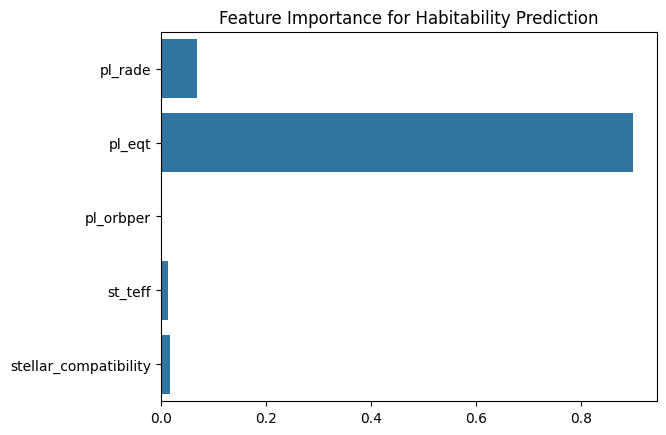

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = pipeline.named_steps['model'].feature_importances_

sns.barplot(x=importances, y=features)
plt.title("Feature Importance for Habitability Prediction")
plt.show()


In [10]:
import joblib

joblib.dump(pipeline, "../models/habitability_pipeline.pkl")

print("Model saved successfully")


Model saved successfully


## Week 3 Summary

In this phase, the cleaned dataset was transformed into a machine learning-ready format.

A binary habitability target variable was defined using an engineered habitability score.

Relevant planetary and stellar features were selected based on scientific reasoning 
and correlation analysis.

The dataset was split into training and testing sets using an 80:20 ratio, 
with stratification applied to preserve class balance.

A machine learning pipeline was implemented using MinMax scaling and 
Random Forest classification to ensure scalability and prevent data leakage.

The model was evaluated using classification metrics such as precision, recall, 
F1-score, and ROC-AUC.

Finally, the trained model was saved for further use in prediction and deployment.
